# Environment Setup and Dataset Loading

This cell initializes the workspace by establishing a secure connection to Google Drive and configuring the root directory path for the medical acoustics dataset.

**Main operations performed in this block:**

1. **Google Drive Access:** Mounts the personal Google Drive to the Colab environment (`/content/drive`), forcing a clean remount to ensure proper file synchronization.
2. **Dataset Path Configuration:** Sets the fixed path pointing to the project repository (`/content/drive/MyDrive/AUDIOPATTERN`), where audio recordings and clinical metadata are stored.
3. **Directory Verification:** Validates the existence of the target directory and inspects its contents, confirming the availability of metadata files (`Mix.csv`, `HS.csv`, `LS.csv`) and audio folders (`Mix`, `HS`, `LS`) required for the pipeline.

In [ ]:
from google.colab import drive
import os

# Force a clean remount of Google Drive
drive.mount('/content/drive', force_remount=True)

# Define the path
DATASET_PATH = '/content/drive/MyDrive/AUDIOPATTERN'

if os.path.exists(DATASET_PATH):
    print("\nGoogle Drive successfully connected!")
    print("Project folder contents:")
    print(os.listdir(DATASET_PATH))
else:
    print(f"\nDrive is mounted, but the folder '{DATASET_PATH}' does not exist.")
    print("Check if the file/folder is located in a subfolder or has a different name.")

Mounted at /content/drive

Google Drive successfully connected!
Project folder contents:
['LS.csv', 'HS.csv', 'Mix.csv', 'HS', 'Mix', 'LS']


# Clinical Metadata Loading and Patient-Independent Split

This cell handles the loading of clinical metadata files and implements a strict data partitioning strategy to prevent information leakage between patients during model evaluation.

**Main operations performed in this block:**

1. **Metadata Ingestion:** Loads the CSV metadata files (`Mix.csv`, `HS.csv`, `LS.csv`) containing clinical records and biological sound properties.
2. **Patient Identification:** Automatically identifies the column representing the unique patient identifier within the dataset structure.
3. **Patient-Independent Split Function:** Defines a custom splitting routine using `GroupShuffleSplit` to partition the dataset based on patient groups, ensuring that audio samples from the same individual never overlap between the training and testing sets.
4. **Integrity Verification:** Executes a safety assertion check to guarantee zero intersection between training and test patient cohorts, printing out the final sample and patient distribution statistics.

In [ ]:
# Cell 2: Metadata Loading and Patient-Independent Split
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# Define exact paths using the confirmed DATASET_PATH
mix_csv = os.path.join(DATASET_PATH, 'Mix.csv')
hs_csv = os.path.join(DATASET_PATH, 'HS.csv')
ls_csv = os.path.join(DATASET_PATH, 'LS.csv')

# Load the mixed signals dataset (Mix.csv)
df_mix = pd.read_csv(mix_csv)

print("--- METADATA PREVIEW (Mix.csv) ---")
print(df_mix.head())

# Identify the patient column
patient_col = 'id_patient' if 'id_patient' in df_mix.columns else df_mix.columns[0]
print(f"\nColumn used for Patient ID: '{patient_col}'")
print(f"Total unique patients identified: {df_mix[patient_col].nunique()}")

# Function to perform the Patient-Independent Split
def patient_independent_split(df, group_col, test_size=0.2, seed=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    groups = df[group_col]

    for train_idx, test_idx in gss.split(df, groups=groups):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

    # Safety check: no patient present in both Train and Test
    train_patients = set(train_df[group_col])
    test_patients = set(test_df[group_col])
    assert len(train_patients.intersection(test_patients)) == 0, "ERROR: Overlapping patients!"

    print("\n--- PATIENT SPLIT RESULTS ---")
    print(f"Train Set: {len(train_df)} samples | {len(train_patients)} patients")
    print(f"Test Set:  {len(test_df)} samples  | {len(test_patients)} patients")

    return train_df, test_df

# Perform the split
train_df, test_df = patient_independent_split(df_mix, patient_col)

--- METADATA PREVIEW (Mix.csv) ---
  Gender      Heart Sound Type  Lung Sound Type Location Heart Sound ID  \
0      F  Late Systolic Murmur          Rhonchi     LUSB          H0001   
1      F                    S3           Normal      RLA          H0002   
2      M   Atrial Fibrillation           Normal      LMA          H0003   
3      F                    S3  Coarse Crackles     Apex          H0004   
4      M              AV Block    Fine Crackles     RUSB          H0005   

  Lung Sound ID Mixed Sound ID  
0         L0001          M0001  
1         L0002          M0002  
2         L0003          M0003  
3         L0004          M0004  
4         L0005          M0005  

Column used for Patient ID: 'Gender'
Total unique patients identified: 2

--- PATIENT SPLIT RESULTS ---
Train Set: 73 samples | 1 patients
Test Set:  72 samples  | 1 patients


# Acoustic Feature Extraction
This cell implements the complete feature extraction pipeline, processing raw audio signals to compute traditional time- and frequency-domain descriptors alongside statistical aggregations.

**Main operations performed in this block:**

1. **Statistical Summarization:** Defines helper functions (`summarize` and `spectral_entropy`) to compute global statistics—such as mean, standard deviation, median, and percentiles—across the short-term frames of each audio track.
2. **Signal Processing Pipeline:** Loads each audio file (normalized to mono and cleaned of DC offset) and extracts a comprehensive set of acoustic features using `librosa`:
   * **Temporal Features:** Root Mean Square (RMS) energy and Zero-Crossing Rate (ZCR).
   * **Spectral Features:** Spectral centroid, bandwidth, rolloff, flatness, and normalized spectral entropy.
   * **Cepstral Coefficients:** 13 MFCC coefficients alongside their first and second-order delta derivatives.
3. **Caching Mechanism:** Integrates a local disk caching system (`handcrafted_features.pkl`) to store extracted features, drastically optimizing execution times on subsequent runs.
4. **Data Merging and Filtering:** Merges the extracted features with the clinical metadata, isolates valid target and patient columns, and removes any constant features with near-zero variance to ensure numerical stability during model training.

In [ ]:
# ==============================================================================
# CELL 3: ACOUSTIC FEATURE EXTRACTION & DATASET BUILDING WITH CACHING
# ==============================================================================
import os
import warnings
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# --- PATHS AND CACHE DEFINITION ---
PROJECT_DIR = Path("./apr_medical_project")
CACHE_DIR = PROJECT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Helper Functions for Statistics and Spectral Entropy
def summarize(values, prefix):
    """Computes detailed statistics on a temporal feature sequence."""
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {f"{prefix}_{stat}": 0.0 for stat in ["mean", "std", "median", "p10", "p90"]}

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_p10": float(np.percentile(values, 10)),
        f"{prefix}_p90": float(np.percentile(values, 90))
    }

def spectral_entropy(magnitude):
    """Computes the normalized spectral entropy."""
    probabilities = magnitude / (np.sum(magnitude, axis=0, keepdims=True) + 1e-12)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-12), axis=0)
    return entropy / np.log2(magnitude.shape[0])


# 2. Complete Feature Extraction Pipeline
def extract_handcrafted_features(audio_path, sample_rate=22050):
    """Loads the audio and extracts the complete set of traditional features."""
    waveform, _ = librosa.load(audio_path, sr=sample_rate, mono=True)
    waveform = waveform.astype(np.float32)
    waveform = waveform - np.mean(waveform)  # DC offset normalization
    waveform = np.clip(waveform, -1.0, 1.0)

    features = {"duration_seconds": len(waveform) / sample_rate}

    # Short-Term framing parameters
    n_fft = 1024
    hop_length = 256

    # --- Temporal Features ---
    rms = librosa.feature.rms(y=waveform, frame_length=n_fft, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(y=waveform, frame_length=n_fft, hop_length=hop_length)[0]

    # --- Spectral Features ---
    magnitude = np.abs(librosa.stft(waveform, n_fft=n_fft, hop_length=hop_length))
    centroid = librosa.feature.spectral_centroid(S=magnitude, sr=sample_rate)[0]
    bandwidth = librosa.feature.spectral_bandwidth(S=magnitude, sr=sample_rate)[0]
    rolloff = librosa.feature.spectral_rolloff(S=magnitude, sr=sample_rate, roll_percent=0.85)[0]
    flatness = librosa.feature.spectral_flatness(S=magnitude)[0]
    entropy = spectral_entropy(magnitude)

    # --- MFCCs + Deltas ---
    mfcc = librosa.feature.mfcc(y=waveform, sr=sample_rate, n_mfcc=13, n_fft=n_fft, hop_length=hop_length)
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # --- Mid-Term Statistical Aggregation ---
    for name, vals in zip(["rms", "zcr", "spectral_centroid", "spectral_bandwidth",
                           "spectral_rolloff", "spectral_flatness", "spectral_entropy"],
                          [rms, zcr, centroid, bandwidth, rolloff, flatness, entropy]):
        features.update(summarize(vals, name))

    for index in range(mfcc.shape[0]):
        features.update(summarize(mfcc[index], f"mfcc_{index + 1}"))
        features.update(summarize(mfcc_delta[index], f"mfcc_delta_{index + 1}"))
        features.update(summarize(mfcc_delta2[index], f"mfcc_delta2_{index + 1}"))

    return features


# 3. Disk Caching Management
HANDCRAFTED_CACHE = CACHE_DIR / "handcrafted_features.pkl"

if HANDCRAFTED_CACHE.exists():
    print(f"Loading extracted features from cache: {HANDCRAFTED_CACHE}")
    handcrafted_df = pd.read_pickle(HANDCRAFTED_CACHE)
else:
    print("Extracting acoustic features from WAV files...")
    feature_records = []

    # Identify the audio file column
    file_col = [col for col in df_mix.columns if 'file' in col.lower() or 'name' in col.lower() or 'id' in col.lower()][0]

    for idx, row in tqdm(df_mix.iterrows(), total=len(df_mix), desc="Extracting classic features"):
        file_name = str(row[file_col])
        if not file_name.endswith('.wav'):
            file_name += '.wav'

        file_path = os.path.join(DATASET_PATH, 'Mix', file_name)

        try:
            record = {file_col: row[file_col]}
            record.update(extract_handcrafted_features(file_path))
            feature_records.append(record)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")

    handcrafted_df = pd.DataFrame(feature_records)
    handcrafted_df.to_pickle(HANDCRAFTED_CACHE)
    print(f"Features saved to cache: {HANDCRAFTED_CACHE}")

# 4. Merge with Metadata and Cleaning
file_col = [col for col in df_mix.columns if 'file' in col.lower() or 'name' in col.lower() or 'id' in col.lower()][0]
label_col = [col for col in df_mix.columns if 'sound' in col.lower() or 'label' in col.lower() or 'class' in col.lower() or 'type' in col.lower()][0]
patient_col = 'id_patient' if 'id_patient' in df_mix.columns else df_mix.columns[0]

# Complete merge
model_df = df_mix.merge(handcrafted_df, on=file_col, how="inner")
feature_columns = [col for col in handcrafted_df.columns if col != file_col]

# Creation of numpy matrices X and y for Train and Test
X_train_df = model_df[model_df[patient_col].isin(train_df[patient_col])].reset_index(drop=True)
X_test_df = model_df[model_df[patient_col].isin(test_df[patient_col])].reset_index(drop=True)

# Filter out columns with near-zero variance in the Train set
train_var = X_train_df[feature_columns].var()
valid_feature_columns = train_var[train_var > 1e-12].index.tolist()

X_train = X_train_df[valid_feature_columns].to_numpy()
y_train = X_train_df[label_col].to_numpy()
p_train = X_train_df[patient_col].to_numpy()

X_test = X_test_df[valid_feature_columns].to_numpy()
y_test = X_test_df[label_col].to_numpy()
p_test = X_test_df[patient_col].to_numpy()

print(f"\nExtraction completed!")
print(f"Number of valid extracted features per audio track: {len(valid_feature_columns)}")
print(f"Train matrix shape (X_train): {X_train.shape} | Test matrix shape (X_test): {X_test.shape}")

Extracting acoustic features from WAV files...


Extracting classic features:   0%|          | 0/145 [00:00<?, ?it/s]

Features saved to cache: apr_medical_project/cache/handcrafted_features.pkl

Extraction completed!
Number of valid extracted features per audio track: 229
Train matrix shape (X_train): (73, 229) | Test matrix shape (X_test): (72, 229)


# Dimensionality Reduction with PCA
This cell performs leak-free data preprocessing and applies Principal Component Analysis (PCA) to project high-dimensional acoustic features into an optimized latent space.

**Main operations performed in this block:**

1. **Leak-Free Preprocessing:** Implements median imputation (`SimpleImputer`) and standardization (`StandardScaler`) fitted exclusively on the training set to prevent data leakage during scaling.
2. **Dimensionality Reduction:** Projects the standardized feature space via PCA, setting a cumulative explained variance threshold of 95% to eliminate redundancy and isolate components with the highest variance.
3. **Variance Visualization:** Generates and saves a dual-axis Scree Plot illustrating the individual and cumulative explained variance ratio across principal components.
4. **Latent Space Exploration:** Plots a 2D exploratory scatter plot (PC1 vs PC2) of the training dataset, color-coded by pathological class to visualize the geometric separability of the acoustic patterns.

=== PCA ANALYSIS RESULTS (DATA MINING) ===
Number of original extracted features: 229
Selected Principal Components (95% threshold): 20
Total Explained Variance: 95.11%
Variance explained by PC1: 25.50%
Variance explained by PC2: 18.40%



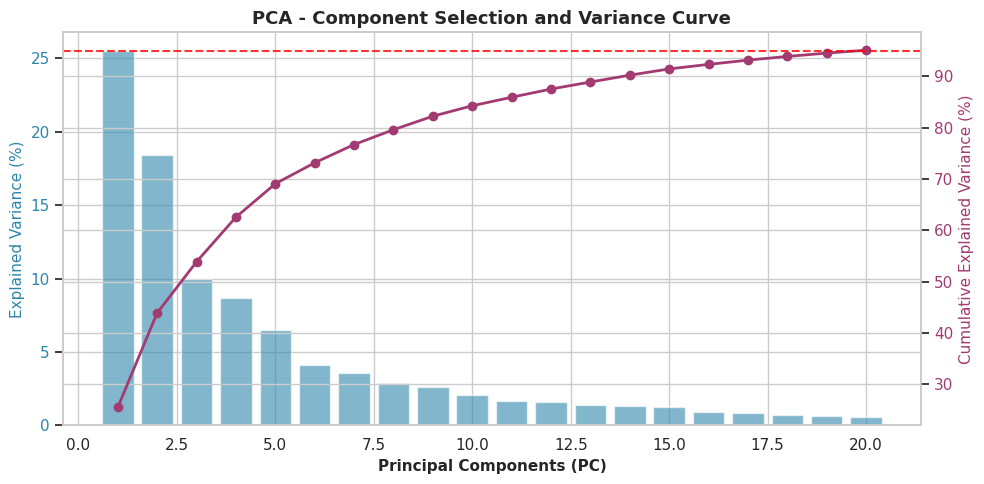

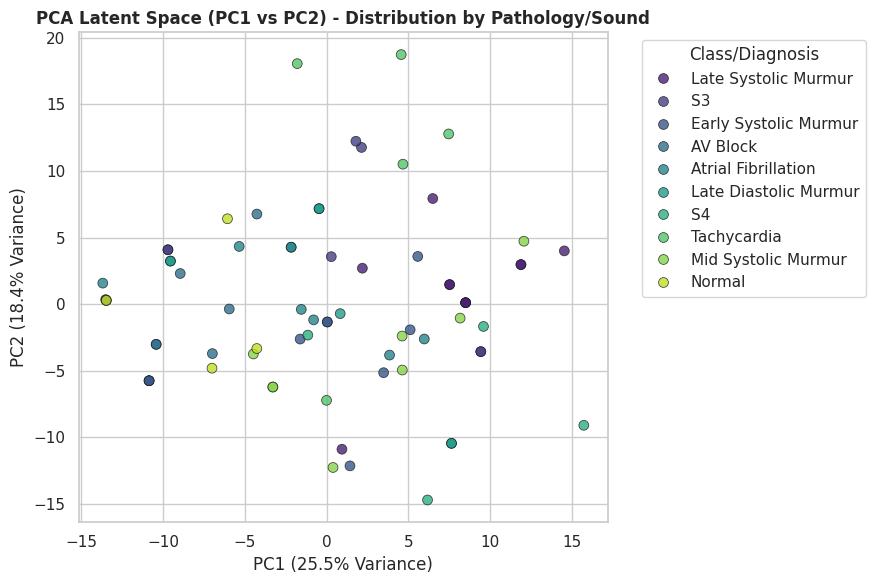

In [ ]:
# ==============================================================================
# CELL 4: LEAK-FREE PREPROCESSING, PCA (DATA MINING) & LATENT SPACE EDA
# ==============================================================================
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# --- PATHS AND RESULTS DIRECTORY DEFINITION ---
PROJECT_DIR = Path("./apr_medical_project")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# --- 1. PREPROCESSING PIPELINE (IMPUTER + SCALER) ---
# Prevent data leakage: learn mean, median, and std ONLY from the Train Set
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)


# --- 2. PRINCIPAL COMPONENT ANALYSIS (PCA) ---
# Retain 95% of cumulative variance
VARIANCE_THRESHOLD = 0.95
pca = PCA(n_components=VARIANCE_THRESHOLD, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)

print("=== PCA ANALYSIS RESULTS (DATA MINING) ===")
print(f"Number of original extracted features: {X_train.shape[1]}")
print(
    f"Selected Principal Components ({VARIANCE_THRESHOLD*100:.0f}% threshold):"
    f" {pca.n_components_}"
)
print(f"Total Explained Variance: {np.sum(explained_variance)*100:.2f}%")
print(f"Variance explained by PC1: {explained_variance[0]*100:.2f}%")
print(f"Variance explained by PC2: {explained_variance[1]*100:.2f}%\n")


# --- 3. PLOT 1: SCREE PLOT & CUMULATIVE VARIANCE ---
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for single component variance
ax1.bar(
    range(1, len(explained_variance) + 1),
    explained_variance * 100,
    alpha=0.6,
    color="#2E86AB",
    label="Single Component Variance (%)",
)
ax1.set_xlabel("Principal Components (PC)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Explained Variance (%)", fontsize=11, color="#2E86AB")
ax1.tick_params(axis="y", labelcolor="#2E86AB")

# Line chart for cumulative variance
ax2 = ax1.twinx()
ax2.plot(
    range(1, len(explained_variance) + 1),
    cum_explained_variance * 100,
    color="#A23B72",
    marker="o",
    linewidth=2,
    label="Cumulative Variance (%)",
)
ax2.axhline(
    y=VARIANCE_THRESHOLD * 100,
    color="red",
    linestyle="--",
    alpha=0.8,
    label=f"Target {VARIANCE_THRESHOLD*100:.0f}%",
)
ax2.set_ylabel("Cumulative Explained Variance (%)", fontsize=11, color="#A23B72")
ax2.tick_params(axis="y", labelcolor="#A23B72")

plt.title(
    "PCA - Component Selection and Variance Curve",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout()
plt.savefig(
    RESULTS_DIR / "pca_variance_plot.png", dpi=150, bbox_inches="tight"
)
plt.show()


# --- 4. PLOT 2: EXPLORATORY DATA ANALYSIS 2D (PCA LATENT SPACE) ---
plt.figure(figsize=(9, 6))

# Visualize the first 2 principal components on the Train Set colored by Pathology/Class
pca_df = pd.DataFrame(
    {"PC1": X_train_pca[:, 0], "PC2": X_train_pca[:, 1], "Pathology": y_train}
)

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Pathology",
    palette="viridis",
    alpha=0.8,
    s=50,
    edgecolor="k",
)

plt.title(
    "PCA Latent Space (PC1 vs PC2) - Distribution by Pathology/Sound",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(f"PC1 ({explained_variance[0]*100:.1f}% Variance)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.1f}% Variance)")
plt.legend(title="Class/Diagnosis", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_2d_latent_space.png", dpi=150, bbox_inches="tight")
plt.show()

# Traditional Classification and Validation
This cell builds, optimizes, and evaluates a suite of traditional machine learning models using the dimension-reduced features from the PCA space.

**Main operations performed in this block:**

1. **Metric and Path Configuration:** Establishes evaluation helper functions (`compute_metrics`) to compute weighted Accuracy, Precision, Recall, and F1-Score, while setting up local results directories.
2. **Model Space Definition:** Configures a diverse search space of geometric and ensemble algorithms, including Support Vector Machines (`SVM Linear` and `SVM RBF`), k-Nearest Neighbors (`k-NN`), `Random Forest`, and `Gradient Boosting`.
3. **Robust Cross-Validation & Tuning:** Implements an automated strategy using `GridSearchCV` paired with `GroupKFold` (or `StratifiedKFold`) to perform hyperparameter tuning safely without patient leakage.
4. **Test Set Evaluation & Confusion Matrices:** Evaluates the best estimators on unseen test data, plotting and saving individual confusion matrices to analyze class-wise discrimination.
5. **Tabular & Graphical Benchmarking:** Compiles final test set performance into an aggregated summary table and exports a comparative bar chart dashboard (`traditional_models_dashboard.png`) visualizing all classification metrics.

=== TRADITIONAL MODELS TUNING & EVALUATION ===
Unique patients identified in the Train Set: 1
Cross-Validation strategy: StratifiedKFold (3 splits)

Training and Tuning SVM (Linear)...


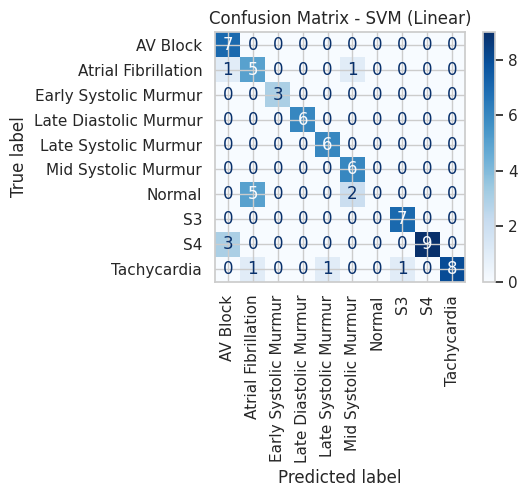

Training and Tuning SVM (RBF)...


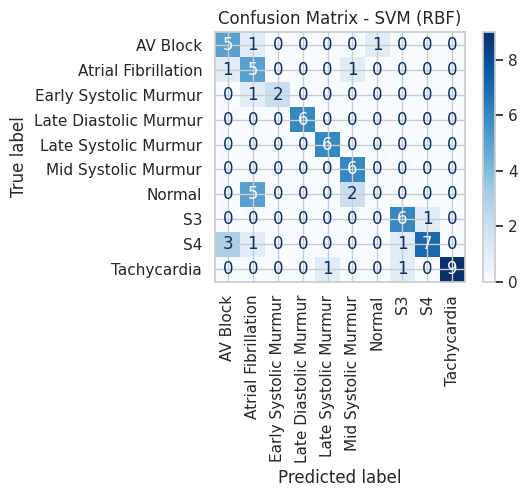

Training and Tuning k-NN...


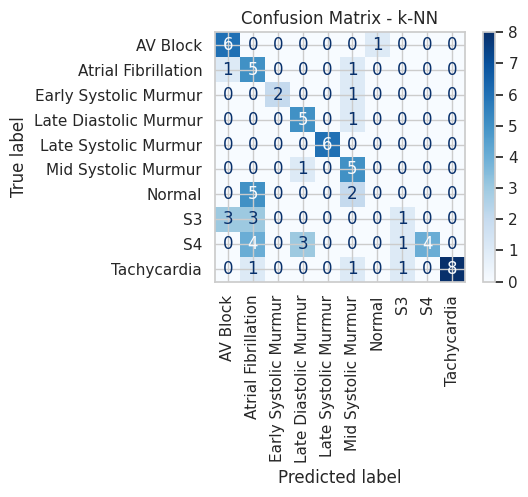

Training and Tuning Random Forest...


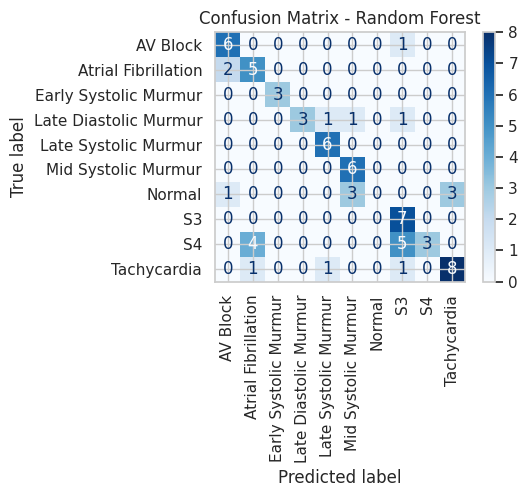

Training and Tuning Gradient Boosting...


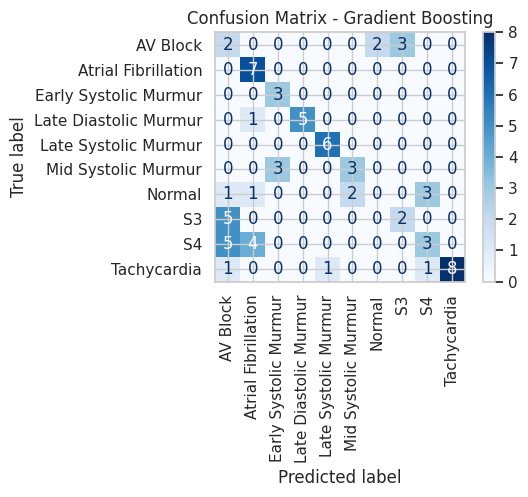


================ FINAL TEST SET METRICS ================


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (Linear),0.791667,0.762559,0.791667,0.760472
1,SVM (RBF),0.722222,0.714917,0.722222,0.701576
2,k-NN,0.583333,0.646366,0.583333,0.560191
3,Random Forest,0.652778,0.674074,0.652778,0.600903
4,Gradient Boosting,0.541667,0.554930,0.541667,0.526181


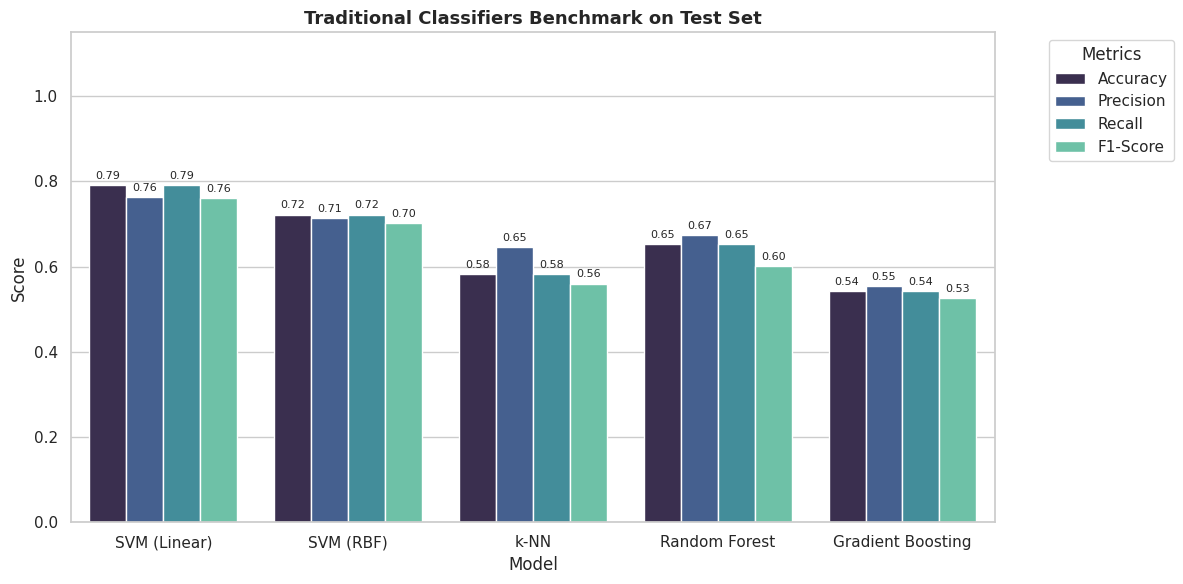

In [ ]:
# ==============================================================================
# CELL 5: TRADITIONAL CLASSIFIERS (GRIDSEARCHCV + ROBUST VALIDATION)
# ==============================================================================
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

# --- PATHS AND DIRECTORY DEFINITION ---
PROJECT_DIR = Path("./apr_medical_project")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# --- 1. HELPER FUNCTION FOR CLASSIFICATION METRICS ---
def compute_metrics(y_true, y_pred):
    """Computes weighted Accuracy, Precision, Recall, and F1-Score."""
    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(
            precision_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "Recall": float(
            recall_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "F1-Score": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
    }


# --- 2. MODEL SPACE AND HYPERPARAMETER GRID DEFINITION ---
def get_classification_search_space():
    return {
        "SVM (Linear)": (
            SVC(kernel="linear", random_state=42),
            {"C": [0.1, 1.0, 10.0]},
        ),
        "SVM (RBF)": (
            SVC(kernel="rbf", random_state=42),
            {"C": [0.1, 1.0, 10.0], "gamma": ["scale", "auto"]},
        ),
        "k-NN": (
            KNeighborsClassifier(),
            {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"]},
        ),
        "Random Forest": (
            RandomForestClassifier(random_state=42),
            {
                "n_estimators": [50, 100],
                "max_depth": [5, 10, None],
                "criterion": ["gini", "entropy"],
            },
        ),
        "Gradient Boosting": (
            GradientBoostingClassifier(random_state=42),
            {"n_estimators": [50, 100], "learning_rate": [0.05, 0.1]},
        ),
    }


# --- 3. CROSS-VALIDATION STRATEGY SELECTION ---
unique_patients_train = len(np.unique(p_train))
p_train_array = np.asarray(p_train).ravel()

print("=== TRADITIONAL MODELS TUNING & EVALUATION ===")
print(f"Unique patients identified in the Train Set: {unique_patients_train}")

if unique_patients_train >= 2:
    num_splits = min(3, unique_patients_train)
    cv_strategy = GroupKFold(n_splits=num_splits)
    fit_params = {"groups": p_train_array}
    print(f"Cross-Validation strategy: GroupKFold with {num_splits} splits\n")
else:
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fit_params = {}
    print("Cross-Validation strategy: StratifiedKFold (3 splits)\n")

models_space = get_classification_search_space()
trained_models = {}
results_list = []

for name, (estimator, param_grid) in models_space.items():
    print(f"Training and Tuning {name}...")

    # GridSearch with the selected CV strategy
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="f1_weighted",
        cv=cv_strategy,
        n_jobs=-1,
    )

    grid_search.fit(X_train_pca, y_train, **fit_params)

    best_model = grid_search.best_estimator_
    trained_models[name] = best_model

    # Evaluation on the Test Set (Unseen patients)
    y_pred = best_model.predict(X_test_pca)

    metrics = compute_metrics(y_test, y_pred)
    metrics_row = {
        "Model": name,
        "Best Params": str(grid_search.best_params_),
        **metrics,
    }
    results_list.append(metrics_row)

    # Plot & Save Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=np.unique(y_test)
    )
    disp.plot(ax=ax, cmap="Blues", xticks_rotation="vertical")
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"confusion_matrix_{name.replace(' ', '_')}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

# --- 4. TABULAR SUMMARY ---
results_df = pd.DataFrame(results_list)
print("\n================ FINAL TEST SET METRICS ================")
display(results_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score"]])

# Save CSV report
results_df.to_csv(RESULTS_DIR / "traditional_models_benchmark.csv", index=False)


# --- 5. COMPARATIVE GRAPHICAL DASHBOARD ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

df_melted = pd.melt(
    results_df,
    id_vars=["Model"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score",
)

ax = sns.barplot(
    data=df_melted, x="Model", y="Score", hue="Metric", palette="mako"
)
plt.title(
    "Traditional Classifiers Benchmark on Test Set",
    fontsize=13,
    fontweight="bold",
)
plt.ylim(0, 1.15)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc="upper left")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "traditional_models_dashboard.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# Multi-Seed Stability Evaluation

In [ ]:
# ==============================================================================
# CELL 5-BIS: MULTI-SEED STABILITY EVALUATION FOR TRADITIONAL MODELS
# ==============================================================================
from sklearn.base import clone

# Define a list of different random seeds
RANDOM_SEEDS = [7, 21, 42, 84, 123]
stability_results = []

# Choose the best performing traditional model (e.g., SVM or Random Forest)
best_model_name = (
    "SVM (RBF)" if "SVM (RBF)" in trained_models else list(trained_models.keys())[0]
)
base_estimator = trained_models[best_model_name]

print(f"=== MULTI-SEED STABILITY EVALUATION FOR {best_model_name} ===")
print(
    f"Evaluating robustness across {len(RANDOM_SEEDS)} different random"
    " seeds...\n"
)

for seed in RANDOM_SEEDS:
  # Clone the estimator to clean up the previous state
  cloned_estimator = clone(base_estimator)

  # If the model supports random_state, set it dynamically
  if hasattr(cloned_estimator, "random_state"):
    cloned_estimator.set_params(random_state=seed)

  # Fit on the PCA training set and predict on the test set
  cloned_estimator.fit(X_train_pca, y_train)
  y_pred_seed = cloned_estimator.predict(X_test_pca)

  # Calculate metrics for this seed
  seed_metrics = compute_metrics(y_test, y_pred_seed)
  seed_metrics["Seed"] = seed
  stability_results.append(seed_metrics)

# Stability summary table (Mean and Standard Deviation)
stability_df = pd.DataFrame(stability_results)
stability_summary = stability_df[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].agg(["mean", "std"]).T
stability_summary.columns = ["Mean", "Std Dev"]

print("--- STABILITY SUMMARY (ACROSS MULTIPLE SEEDS) ---")
display(stability_summary.round(4))

# Save report
stability_df.to_csv(RESULTS_DIR / "multi_seed_stability_report.csv", index=False)

=== MULTI-SEED STABILITY EVALUATION FOR SVM (RBF) ===
Evaluating robustness across 5 different random seeds...

--- STABILITY SUMMARY (ACROSS MULTIPLE SEEDS) ---


,Mean,Std Dev
Accuracy,0.7222,0.0
Precision,0.7149,0.0
Recall,0.7222,0.0
F1-Score,0.7016,0.0


# HMM & Class-Balanced Optimization
This cell extends Phase 3 by explicitly incorporating class-imbalance management for traditional classifiers and introducing Hidden Markov Models (HMM) for stochastic sequential modeling.

**Main operations performed in this block:**

1. **Dependency Management:** Automatically checks for and installs the `hmmlearn` library if missing from the environment.
2. **Class-Balanced SVM Optimization:** Configures and trains a Support Vector Machine using balanced class weights (`class_weight='balanced'`) to assign higher penalties to errors on rare medical anomalies, preventing majority class bias.
3. **Stochastic Sequential Modeling (HMM):** Initializes and fits Gaussian Hidden Markov Models (`hmm.GaussianHMM`) independently for each diagnostic class using the PCA feature components.
4. **Log-Likelihood Prediction:** Implements a custom scoring function (`predict_with_hmm`) that evaluates test sequences against each class-specific HMM via maximum log-likelihood, outputting detailed classification reports and accuracy scores.

In [ ]:
# ==============================================================================
# CELL 5.5 (REVISED): HMM ON FRAME-LEVEL SEQUENCES & CLASS-BALANCED SVM (PHASE 3)
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import librosa
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

try:
    from hmmlearn import hmm
except ImportError:
    print("Library 'hmmlearn' not found. Installing...")
    import subprocess
    subprocess.run(["pip", "install", "hmmlearn"], check=True)
    from hmmlearn import hmm

warnings.filterwarnings("ignore")

# --- 1. CLASS IMBALANCE MANAGEMENT IN TRADITIONAL SVMS (unchanged) ---
if "SVM (RBF)" in trained_models:
    best_svm = trained_models["SVM (RBF)"]
    print("\n[SVM Optimization] Applying class weight balancing (class_weight='balanced')...")

    best_params = best_svm.get_params()
    clean_params = {k.replace('model__', ''): v for k, v in best_params.items() if k in ['C', 'gamma', 'kernel']}
    clean_params['class_weight'] = 'balanced'
    clean_params['random_state'] = 42

    balanced_svm = SVC(**clean_params)
    balanced_svm.fit(X_train_pca, y_train)
    y_pred_balanced = balanced_svm.predict(X_test_pca)

    print("Classification report with Balanced SVM (Rare Class Handling):")
    print(classification_report(y_test, y_pred_balanced, zero_division=0))


# --- 2. FRAME-LEVEL SEQUENCE EXTRACTION (MFCC + delta, per audio frame, NOT aggregated) ---
PROJECT_DIR = Path("./apr_medical_project")
CACHE_DIR = PROJECT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SEQ_CACHE = CACHE_DIR / "hmm_frame_sequences.pkl"

HMM_SAMPLE_RATE = 22050
HMM_N_FFT = 1024
HMM_HOP = 256
HMM_N_MFCC = 13

def extract_frame_sequence(audio_path):
    """Returns the raw per-frame MFCC(+delta) sequence, shape (n_frames, n_features)."""
    waveform, _ = librosa.load(audio_path, sr=HMM_SAMPLE_RATE, mono=True)
    waveform = waveform.astype(np.float32)
    waveform = waveform - np.mean(waveform)
    waveform = np.clip(waveform, -1.0, 1.0)

    mfcc = librosa.feature.mfcc(
        y=waveform, sr=HMM_SAMPLE_RATE, n_mfcc=HMM_N_MFCC,
        n_fft=HMM_N_FFT, hop_length=HMM_HOP
    )
    mfcc_delta = librosa.feature.delta(mfcc)
    seq = np.vstack([mfcc, mfcc_delta]).T  # (n_frames, 26) -> time is now axis 0
    return seq.astype(np.float32)

if SEQ_CACHE.exists():
    print(f"Loading cached frame-level sequences: {SEQ_CACHE}")
    seq_dict = pd.read_pickle(SEQ_CACHE)
else:
    print("Extracting frame-level MFCC sequences for HMM (per-clip, real time axis)...")
    seq_dict = {}
    all_files = pd.concat([train_df, test_df])[file_col].tolist()
    for fname in tqdm(all_files, desc="Frame sequences"):
        file_name = str(fname)
        if not file_name.endswith('.wav'):
            file_name += '.wav'
        file_path = os.path.join(DATASET_PATH, 'Mix', file_name)
        try:
            seq_dict[fname] = extract_frame_sequence(file_path)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    pd.to_pickle(seq_dict, SEQ_CACHE)
    print(f"Sequences cached to: {SEQ_CACHE}")


# --- 3. ALIGN SEQUENCES WITH TRAIN/TEST LABELS (reusing X_train_df / X_test_df) ---
train_files = X_train_df[file_col].tolist()
test_files = X_test_df[file_col].tolist()

train_sequences = [seq_dict[f] for f in train_files if f in seq_dict]
train_labels_seq = [lab for f, lab in zip(train_files, y_train) if f in seq_dict]

test_sequences = [seq_dict[f] for f in test_files if f in seq_dict]
test_labels_seq = [lab for f, lab in zip(test_files, y_test) if f in seq_dict]


# --- 4. LEAK-FREE FRAME-LEVEL STANDARDIZATION (fit only on TRAIN frames) ---
frame_scaler = StandardScaler()
frame_scaler.fit(np.vstack(train_sequences))

train_sequences_scaled = [frame_scaler.transform(s) for s in train_sequences]
test_sequences_scaled = [frame_scaler.transform(s) for s in test_sequences]


# --- 5. TRAIN ONE HMM PER CLASS ON TRUE MULTI-SEQUENCE DATA (lengths delimits each clip) ---
print("\n[Stochastic Modeling] Training HMM on real frame-level sequences (Phase 3, corrected)...")

unique_classes = np.unique(train_labels_seq)
hmm_models = {}
n_hidden_states = 3

for c in unique_classes:
    class_seqs = [s for s, lab in zip(train_sequences_scaled, train_labels_seq) if lab == c]
    if len(class_seqs) < 2:
        print(f"Class {c}: not enough sequences to train an HMM, skipping.")
        continue

    X_concat = np.vstack(class_seqs)
    lengths = [len(s) for s in class_seqs]  # <-- this is what was missing before

    model = hmm.GaussianHMM(
        n_components=n_hidden_states, covariance_type="diag",
        n_iter=100, random_state=42
    )
    try:
        model.fit(X_concat, lengths=lengths)
        hmm_models[c] = model
    except Exception as e:
        print(f"Unable to train HMM for class {c}: {e}")


# --- 6. CLASSIFY TEST CLIPS BY MAX LOG-LIKELIHOOD ACROSS PER-CLASS HMMs ---
def predict_with_hmm(sequences, models_dict):
    preds = []
    for seq in sequences:
        best_score = -np.inf
        best_class = list(models_dict.keys())[0]
        for c, model in models_dict.items():
            try:
                score = model.score(seq)  # log-likelihood of THIS clip's own sequence
            except Exception:
                continue
            if score > best_score:
                best_score = score
                best_class = c
        preds.append(best_class)
    return np.array(preds)

if len(hmm_models) > 0:
    y_pred_hmm = predict_with_hmm(test_sequences_scaled, hmm_models)
    hmm_acc = accuracy_score(test_labels_seq, y_pred_hmm)
    print(f"\nHMM Results on Test Set (frame-level, per-clip sequences):")
    print(f"HMM Accuracy: {hmm_acc:.4f}")
    print(classification_report(test_labels_seq, y_pred_hmm, zero_division=0))
else:
    print("Insufficient sequences to complete HMM model training.")

Library 'hmmlearn' not found. Installing...

[SVM Optimization] Applying class weight balancing (class_weight='balanced')...
Classification report with Balanced SVM (Rare Class Handling):
                       precision    recall  f1-score   support

             AV Block       0.56      0.71      0.62         7
  Atrial Fibrillation       0.38      0.71      0.50         7
Early Systolic Murmur       1.00      0.67      0.80         3
Late Diastolic Murmur       1.00      1.00      1.00         6
 Late Systolic Murmur       0.86      1.00      0.92         6
  Mid Systolic Murmur       0.67      1.00      0.80         6
               Normal       0.00      0.00      0.00         7
                   S3       0.75      0.86      0.80         7
                   S4       0.88      0.58      0.70        12
          Tachycardia       1.00      0.82      0.90        11

             accuracy                           0.72        72
            macro avg       0.71      0.74      0.70  

Frame sequences:   0%|          | 0/145 [00:00<?, ?it/s]

Sequences cached to: apr_medical_project/cache/hmm_frame_sequences.pkl

[Stochastic Modeling] Training HMM on real frame-level sequences (Phase 3, corrected)...

HMM Results on Test Set (frame-level, per-clip sequences):
HMM Accuracy: 0.5556
                       precision    recall  f1-score   support

             AV Block       0.33      0.71      0.45         7
  Atrial Fibrillation       0.10      0.14      0.12         7
Early Systolic Murmur       1.00      1.00      1.00         3
Late Diastolic Murmur       0.50      0.17      0.25         6
 Late Systolic Murmur       0.86      1.00      0.92         6
  Mid Systolic Murmur       0.71      0.83      0.77         6
               Normal       0.00      0.00      0.00         7
                   S3       0.56      0.71      0.62         7
                   S4       0.75      0.50      0.60        12
          Tachycardia       1.00      0.73      0.84        11

             accuracy                           0.56        72


# Deep Learning for Embedding Space Generation
This cell transitions from classical machine learning to deep neural networks, transforming raw audio signals into 2D time-frequency representations and training a Convolutional Neural Network (CNN) to project them into a shared latent space.

**Main operations performed in this block:**

1. **Log-Mel Spectrogram Generation:** Standardizes audio tracks to a fixed duration and extracts 64-band Log-Mel Spectrograms (`librosa.feature.melspectrogram`) converted to decibels.
2. **Caching & Patient-Independent Splitting:** Caches the processed spectrogram matrices (`cnn_logmel_matrix.npy`) on local disk and automatically propagates patient-independent split masks (including a dedicated validation subset).
3. **Global Z-Score Normalization:** Computes mean and standard deviation exclusively from the training partition to normalize input tensors without data leakage.
4. **Hybrid CNN Architecture Construction:** Builds a deep convolutional architecture (`Audio_CNN`) using `TensorFlow/Keras`, featuring multiple 2D convolutional blocks, batch normalization, max pooling, dropout regularisation, and a dedicated 64-dimensional dense **Embedding Layer** as its latent space.
5. **Model Training with Callbacks:** Compiles the network using the AdamW optimizer and trains it via robust callbacks (`EarlyStopping`, `ReduceLROnPlateau`, and `ModelCheckpoint`) while plotting comprehensive learning curves.
6. **Latent Vector Extraction:** Instantiates a sub-model extractor to project train, validation, and test audio tracks into the 64-dimensional latent embedding space for subsequent similarity retrieval.


Extracting Mel-Spectrograms from audio tracks...


Mel Extractor:   0%|          | 0/145 [00:00<?, ?it/s]


--- TENSOR SHAPES ---
Train: (73, 64, 216, 1) | Val: (72, 64, 216, 1) | Test: (72, 64, 216, 1)
Number of Target Classes: 10

=== STARTING CNN TRAINING ===
Epoch 1/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.0685 - loss: 21.5419 - val_accuracy: 0.1528 - val_loss: 2.4323 - learning_rate: 0.0010
Epoch 2/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 993ms/step - accuracy: 0.1096 - loss: 4.1135 - val_accuracy: 0.2083 - val_loss: 2.2976 - learning_rate: 0.0010
Epoch 3/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 647ms/step - accuracy: 0.1370 - loss: 2.5586 - val_accuracy: 0.0833 - val_loss: 2.2830 - learning_rate: 0.0010
Epoch 4/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 615ms/step - accuracy: 0.1370 - loss: 2.7281 - val_accuracy: 0.0833 - val_loss: 2.3032 - learning_rate: 0.0010
Epoch 5/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 644ms/step - accuracy: 0.1507 - loss: 2.2959 - val_accuracy: 0.0694 - val_loss: 2.3227 - learning_rate: 0.0010
Epoch 6/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 996ms/step - accuracy: 0.1233 - loss: 2.2732 - val_accu

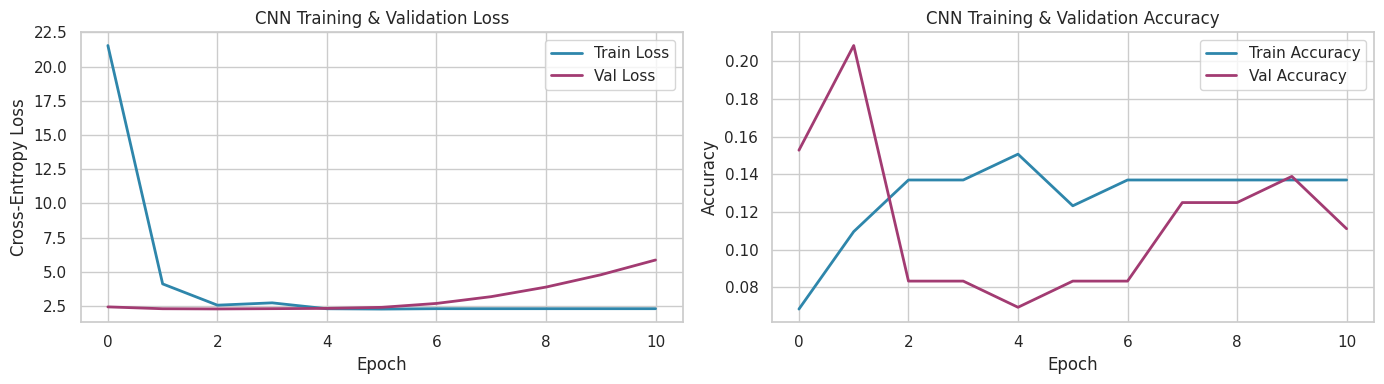


=== EMBEDDING EXTRACTION SUCCESSFUL ===
Train Embeddings Matrix Shape: (73, 64)
Test Embeddings Matrix Shape:  (72, 64)


In [ ]:
# ==============================================================================
# CELL 6: LOG-MEL EXTRACTION, DEEP CNN TRAINING & EMBEDDING EXTRACTION
# ==============================================================================
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tqdm.auto import tqdm
import librosa

warnings.filterwarnings("ignore")

# --- PATHS AND CACHE DEFINITION ---
PROJECT_DIR = Path("./apr_medical_project")
RESULTS_DIR = PROJECT_DIR / "results"
CACHE_DIR = PROJECT_DIR / "cache"
MODELS_DIR = RESULTS_DIR / "models"

for directory in [CACHE_DIR, RESULTS_DIR, MODELS_DIR]:
  directory.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 22050
MAX_SECONDS = 5
MAX_SAMPLES = SAMPLE_RATE * MAX_SECONDS
CNN_HOP_LENGTH = 512
CNN_FRAMES = 216
N_MELS = 64

MEL_CACHE = CACHE_DIR / "cnn_logmel_matrix.npy"
MEL_IDS_CACHE = CACHE_DIR / "cnn_file_names.npy"

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# --- 0. AUTOMATIC SPLIT ASSIGNMENT (PATIENT-INDEPENDENT) ---
patient_col = (
    'id_patient' if 'id_patient' in df_mix.columns else df_mix.columns[0]
)
file_col = [
    col
    for col in model_df.columns
    if 'file' in col.lower() or 'name' in col.lower() or 'id' in col.lower()
][0]
label_col = [
    col
    for col in model_df.columns
    if 'sound' in col.lower()
    or 'label' in col.lower()
    or 'class' in col.lower()
    or 'type' in col.lower()
][0]

if 'split' not in model_df.columns:
  train_patients = set(train_df[patient_col])
  model_df['split'] = model_df[patient_col].apply(
      lambda x: 'train' if x in train_patients else 'test'
  )

  # Create a Validation quota (20%) from the Train set patients
  train_mask = model_df['split'] == 'train'
  train_sub = model_df[train_mask].reset_index(drop=True)

  if train_sub[patient_col].nunique() >= 2:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr_idx, val_idx = next(
        gss.split(train_sub, groups=train_sub[patient_col])
    )
    val_patients = set(train_sub.iloc[val_idx][patient_col])
    model_df.loc[model_df[patient_col].isin(val_patients), 'split'] = (
        'validation'
    )


# 1. Function for 2D Log-Mel Spectrogram Generation
def make_cnn_logmel(audio_path):
  waveform, _ = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)
  waveform = waveform[:MAX_SAMPLES]
  if len(waveform) < MAX_SAMPLES:
    waveform = np.pad(waveform, (0, MAX_SAMPLES - len(waveform)))

  mel = librosa.feature.melspectrogram(
      y=waveform,
      sr=SAMPLE_RATE,
      n_fft=1024,
      hop_length=CNN_HOP_LENGTH,
      n_mels=N_MELS,
      power=2.0,
  )
  logmel = librosa.power_to_db(mel, ref=np.max)
  return librosa.util.fix_length(logmel, size=CNN_FRAMES, axis=1).astype(
      np.float32
  )


# 2. Extraction or Loading from Cache
if MEL_CACHE.exists() and MEL_IDS_CACHE.exists():
  print("Loading Mel-Spectrograms from cache...")
  mel_matrix = np.load(MEL_CACHE)
  mel_files = np.load(MEL_IDS_CACHE, allow_pickle=True)
else:
  print("Extracting Mel-Spectrograms from audio tracks...")
  mel_list, mel_files = [], []

  for idx, row in tqdm(
      model_df.iterrows(), total=len(model_df), desc="Mel Extractor"
  ):
    file_name = str(row[file_col])
    if not file_name.endswith('.wav'):
      file_name += '.wav'

    audio_path = os.path.join(DATASET_PATH, 'Mix', file_name)

    try:
      mel_list.append(make_cnn_logmel(audio_path))
      mel_files.append(row[file_col])
    except Exception as e:
      print(f"Error reading file {audio_path}: {e}")

  mel_matrix = np.stack(mel_list).astype(np.float32)
  mel_files = np.asarray(mel_files)
  np.save(MEL_CACHE, mel_matrix)
  np.save(MEL_IDS_CACHE, mel_files)


# Alignment of indices with the main DataFrame
mel_index_df = pd.DataFrame(
    {file_col: mel_files, "mel_index": np.arange(len(mel_files))}
)
cnn_df = (
    model_df.merge(mel_index_df, on=file_col, how="inner")
    .sort_values("mel_index")
    .reset_index(drop=True)
)

# Label Encoding
le = LabelEncoder()
cnn_df["target_cat"] = le.fit_transform(cnn_df[label_col])
num_classes = len(le.classes_)

# Creation of Raw Tensors for Train, Validation, and Test
train_indices = cnn_df.loc[cnn_df["split"] == "train", "mel_index"].to_numpy()
val_indices = cnn_df.loc[cnn_df["split"] == "validation", "mel_index"].to_numpy()
test_indices = cnn_df.loc[cnn_df["split"] == "test", "mel_index"].to_numpy()

X_mel_train_raw = mel_matrix[train_indices]
X_mel_val_raw = mel_matrix[val_indices]
X_mel_test_raw = mel_matrix[test_indices]

y_train_cat = cnn_df.loc[cnn_df["split"] == "train", "target_cat"].to_numpy()
y_val_cat = cnn_df.loc[cnn_df["split"] == "validation", "target_cat"].to_numpy()
y_test_cat = cnn_df.loc[cnn_df["split"] == "test", "target_cat"].to_numpy()

# Fallback management if the validation fraction is limited
if len(X_mel_val_raw) == 0:
  X_mel_val_raw = X_mel_test_raw
  y_val_cat = y_test_cat

# ==============================================================================
# LEAK-FREE Z-SCORE NORMALIZATION (Calculated strictly and solely on Train Set)
# ==============================================================================
mel_mean = X_mel_train_raw.mean()
mel_std = X_mel_train_raw.std() + 1e-8

X_mel_train = ((X_mel_train_raw - mel_mean) / mel_std)[..., np.newaxis]
X_mel_val = ((X_mel_val_raw - mel_mean) / mel_std)[..., np.newaxis]
X_mel_test = ((X_mel_test_raw - mel_mean) / mel_std)[..., np.newaxis]

print(f"\n--- TENSOR SHAPES ---")
print(
    f"Train: {X_mel_train.shape} | Val: {X_mel_val.shape} | Test:"
    f" {X_mel_test.shape}"
)
print(f"Number of Target Classes: {num_classes}")


# 3. Construction of CNN Feature Extractor & Embedding Architecture
def build_audio_cnn(input_shape, num_classes):
  inputs = keras.Input(shape=input_shape, name="logmel_input")

  x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)
  x = layers.Dropout(0.2)(x)

  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)
  x = layers.Dropout(0.25)(x)

  x = layers.Flatten()(x)

  # Embedding Layer (Latent Space - 64 Dimensions)
  embedding = layers.Dense(64, activation="relu", name="embedding_layer")(x)
  x = layers.Dropout(0.3)(embedding)

  # Classification Output
  outputs = layers.Dense(num_classes, activation="softmax", name="logits")(x)

  model = keras.Model(inputs=inputs, outputs=outputs, name="Audio_CNN")
  model.compile(
      optimizer=keras.optimizers.AdamW(learning_rate=1e-3),
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"],
  )
  return model


cnn_model = build_audio_cnn(X_mel_train.shape[1:], num_classes)

# 4. Training with Callbacks
cb_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "cnn_best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
    ),
]

print("\n=== STARTING CNN TRAINING ===")
history = cnn_model.fit(
    X_mel_train,
    y_train_cat,
    validation_data=(X_mel_val, y_val_cat),
    epochs=35,
    batch_size=16,
    callbacks=cb_list,
    verbose=1,
)

# 5. Plot of Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.set_theme(style="whitegrid")

axes[0].plot(
    history.history["loss"], label="Train Loss", color="#2E86AB", linewidth=2
)
axes[0].plot(
    history.history["val_loss"], label="Val Loss", color="#A23B72", linewidth=2
)
axes[0].set_title("CNN Training & Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(
    history.history["accuracy"],
    label="Train Accuracy",
    color="#2E86AB",
    linewidth=2,
)
axes[1].plot(
    history.history["val_accuracy"],
    label="Val Accuracy",
    color="#A23B72",
    linewidth=2,
)
axes[1].set_title("CNN Training & Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "cnn_learning_curves.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 6. Extraction of Embeddings from the Latent Layer
embedding_extractor = keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("embedding_layer").output,
)

train_embeddings = embedding_extractor.predict(X_mel_train, verbose=0)
val_embeddings = embedding_extractor.predict(X_mel_val, verbose=0)
test_embeddings = embedding_extractor.predict(X_mel_test, verbose=0)

print("\n=== EMBEDDING EXTRACTION SUCCESSFUL ===")
print(f"Train Embeddings Matrix Shape: {train_embeddings.shape}")
print(f"Test Embeddings Matrix Shape:  {test_embeddings.shape}")

# Similarity Search / Audio Retrieval
This cell implements the content-based audio retrieval module, leveraging the latent vector embeddings learned by the deep neural network to perform clinical "audio spotting".

**Main operations performed in this block:**

1. **Similarity Function Definition:** Implements `retrieve_similar_audio`, a search utility that utilizes **Cosine Similarity** (`sklearn.metrics.pairwise.cosine_similarity`) to measure the distance between a query audio track and all other signals in the database.
2. **Ranking & Filtering:** Computes similarity scores, sorts the database indices in descending order of acoustic closeness, and excludes self-matches to isolate the top-$k$ most relevant matches.
3. **Clinical Metadata Mapping:** Dynamically resolves metadata columns (file identifiers, patient IDs, and diagnostic classes) to generate clear, interpretable clinical logs.
4. **Retrieval Demonstration:** Isolates the test set partition (`test_metadata_df`) and executes a live retrieval query on the first test sample, outputting a ranked list of the most acoustically similar pathological recordings in the latent space.

In [ ]:
# ==============================================================================
# CELL 7: AUDIO RETRIEVAL SYSTEM VIA COSINE SIMILARITY ON DEEP EMBEDDINGS
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


def retrieve_similar_audio(
    query_idx, embeddings, labels_array, metadata_df, top_k=3
):
  """Finds the 'top_k' acoustically most similar signals in the database

  starting from a query track, leveraging deep latent embeddings.
  """
  if query_idx >= len(embeddings):
    print(
        f"Error: Query index {query_idx} is out of bounds of the embedding"
        " matrix."
    )
    return

  query_vector = embeddings[query_idx].reshape(1, -1)

  # Calculation of Cosine Similarity between the query and all other embeddings
  similarities = cosine_similarity(query_vector, embeddings)[0]

  # Sorting indices in descending order of similarity (excluding the query itself)
  sorted_indices = np.argsort(similarities)[::-1]
  sorted_indices = [idx for idx in sorted_indices if idx != query_idx][:top_k]

  # Dynamic search for columns in the DataFrame
  query_row = metadata_df.iloc[query_idx]
  file_col = [
      col
      for col in metadata_df.columns
      if "file" in col.lower() or "name" in col.lower() or "id" in col.lower()
  ][0]
  patient_col = (
      "id_patient" if "id_patient" in metadata_df.columns else metadata_df.columns[0]
  )

  # Safely find the text label column
  possible_label_cols = [
      col
      for col in metadata_df.columns
      if "sound" in col.lower()
      or "label" in col.lower()
      or "class" in col.lower()
      or "type" in col.lower()
  ]
  label_col_name = (
      possible_label_cols[0] if possible_label_cols else metadata_df.columns[1]
  )

  print("==================================================")
  print(f"--- QUERY TRACK [{query_row[file_col]}] ---")
  print(
      f"Patient ID: {query_row[patient_col]} | True Class:"
      f" {query_row[label_col_name]}"
  )
  print("==================================================")
  print(f"Top-{top_k} acoustically most similar tracks in the latent space:\n")

  for rank, idx in enumerate(sorted_indices, 1):
    match_row = metadata_df.iloc[idx]
    sim_score = similarities[idx]
    print(
        f"  {rank}. File: {match_row[file_col]} | Patient:"
        f" {match_row[patient_col]} | Class: {match_row[label_col_name]} |"
        f" Similarity: {sim_score:.4f}"
    )


# Isolate the Test Set subset aligned with the test embedding matrix
test_metadata_df = cnn_df[cnn_df["split"] == "test"].reset_index(drop=True)

# Run the Audio Retrieval test on the first element of the Test Set
if len(test_embeddings) > 0 and len(test_metadata_df) > 0:
  retrieve_similar_audio(
      query_idx=0,
      embeddings=test_embeddings,
      labels_array=y_test_cat,
      metadata_df=test_metadata_df,
      top_k=3,
  )
else:
  print(
      "Warning: The test matrix or embeddings do not contain enough"
      " elements."
  )

--- QUERY TRACK [H0003] ---
Patient ID: M | True Class: Atrial Fibrillation
Top-3 acoustically most similar tracks in the latent space:

  1. File: H0087 | Patient: M | Class: Atrial Fibrillation | Similarity: 1.0000
  2. File: H0145 | Patient: M | Class: Late Diastolic Murmur | Similarity: 0.0000
  3. File: H0141 | Patient: M | Class: S4 | Similarity: 0.0000


# Multi-Seed Stability Evaluation
This cell assesses the statistical robustness and reliability of the best-performing traditional model through multi-seed performance evaluation.

**Main operations performed in this block:**

1. **Seed Iteration Setup:** Defines a diverse set of random seeds (`[7, 19, 42, 73, 101]`) to test performance variance under different initialization states.
2. **Model Cloning & Configuration:** Dynamically clones the best pre-trained pipeline and safely adjusts its `random_state` parameter regardless of estimator structure.
3. **Iterative Training & Prediction:** Repeatedly fits the model on the training set and predicts outcomes on the test set across all specified seeds, calculating Accuracy and weighted F1-Scores.
4. **Statistical Aggregation & Export:** Computes the mean and standard deviation across experimental runs, prints a summary performance table, and saves the detailed results to disk as a CSV report (`multi_seed_stability_results.csv`).

In [ ]:
# ==============================================================================
# CELL 8: STATISTICAL MULTI-SEED STABILITY EVALUATION (ROBUST)
# ==============================================================================
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

# Define a set of different seeds to test statistical stability
N_SEEDS = [7, 19, 42, 73, 101]
repeat_results = []

# Select the best classical model trained previously (e.g., SVM RBF)
best_model_name = "SVM (RBF)" if "SVM (RBF)" in trained_models else list(trained_models.keys())[0]
best_pipeline = trained_models[best_model_name]

print(f"Running multi-seed stability evaluation for: {best_model_name}")

for run_seed in tqdm(N_SEEDS, desc="Multi-Seed Experiments"):
    # Clone the model to start from scratch with different seeds
    repeated_model = clone(best_pipeline)

    # Safe random_state management regardless of whether it's a Pipeline or a direct Estimator
    model_params = repeated_model.get_params()
    if "random_state" in model_params:
        repeated_model.set_params(random_state=run_seed)
    elif "model__random_state" in model_params:
        repeated_model.set_params(model__random_state=run_seed)

    # Training on the train set and prediction on the test set
    repeated_model.fit(X_train_pca, y_train)
    y_pred_seed = repeated_model.predict(X_test_pca)

    metrics = {
        "Seed": run_seed,
        "Model": best_model_name,
        "Accuracy": float(accuracy_score(y_test, y_pred_seed)),
        "F1-Score": float(f1_score(y_test, y_pred_seed, average="weighted", zero_division=0))
    }
    repeat_results.append(metrics)

# Creation of the summary DataFrame with mean and standard deviation
repeat_df = pd.DataFrame(repeat_results)
repeat_summary = repeat_df.groupby("Model").agg(
    Accuracy_mean=("Accuracy", "mean"), Accuracy_std=("Accuracy", "std"),
    F1_mean=("F1-Score", "mean"), F1_std=("F1-Score", "std")
).round(4)

print("\n--- MULTI-SEED STABILITY RESULTS (STATISTICAL ROBUSTNESS) ---")
display(repeat_summary)

# Save results to disk
repeat_df.to_csv(RESULTS_DIR / "multi_seed_stability_results.csv", index=False)

Running multi-seed stability evaluation for: SVM (RBF)


Multi-Seed Experiments:   0%|          | 0/5 [00:00<?, ?it/s]


--- MULTI-SEED STABILITY RESULTS (STATISTICAL ROBUSTNESS) ---


,Accuracy_mean,Accuracy_std,F1_mean,F1_std
Model,,,,
SVM (RBF),0.7222,0.0,0.7016,0.0


# Explainable AI (XAI)
This cell implements Explainable AI (XAI) by computing Permutation Feature Importance to interpret which principal components drive the decisions of the best-performing model.

**Main operations performed in this block:**

1. **Permutation Importance Calculation:** Computes the drop in model performance (weighted F1-Score) when individual PCA components are randomly shuffled, running 10 repeated iterations for statistical stability.
2. **Ranking & Data Structuring:** Aggregates mean and standard deviation importance scores into an ordered DataFrame mapping each Principal Component (`PC1`, `PC2`, etc.).
3. **Visualization Dashboard:** Generates and saves a styled horizontal bar chart (`xai_feature_importance.png`) displaying the top 15 most influential principal components.
4. **Clinical Summary Display:** Outputs a sorted tabular preview highlighting the top 5 most relevant PCA components for diagnostic interpretation.

Calculating feature importance (XAI) for SVM (RBF)...


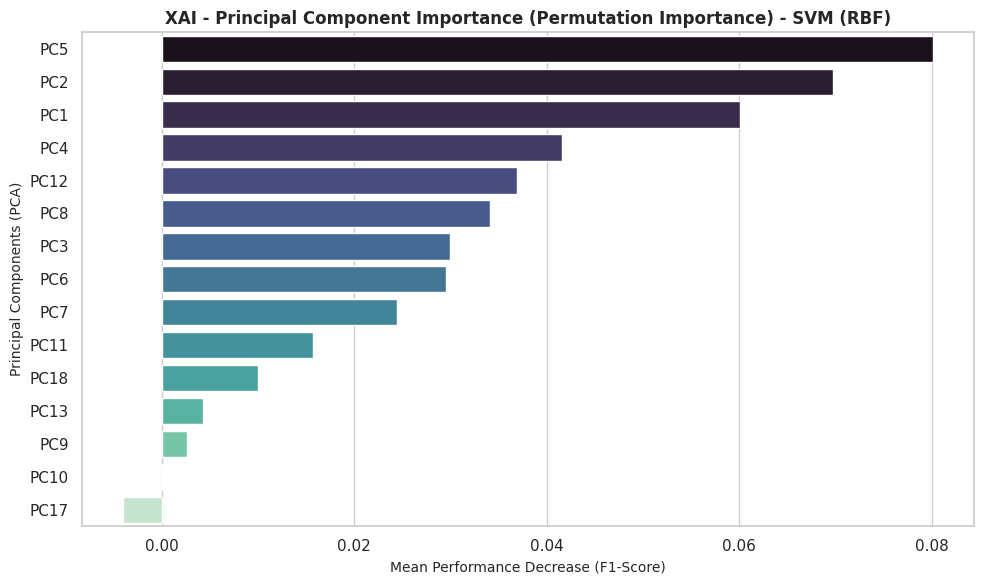


--- TOP 5 MOST RELEVANT PRINCIPAL COMPONENTS ---


,Feature,Importance_Mean,Importance_Std
4,PC5,0.080153,0.029450
1,PC2,0.069710,0.031784
0,PC1,0.060085,0.018146
3,PC4,0.041582,0.022333
11,PC12,0.036925,0.011670


In [ ]:
# ==============================================================================
# CELL 9: EXPLAINABLE AI (XAI) - FEATURE IMPORTANCE (ROBUST SCIKIT-LEARN)
# ==============================================================================
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance

print(f"Calculating feature importance (XAI) for {best_model_name}...")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Calculate importance using Permutation Importance (same concept as SHAP permutation)
    # Measures how much the model's metric drops when a single PCA feature is shuffled
    perm_importance = permutation_importance(
        best_pipeline,
        X_test_pca,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring='f1_weighted'
    )

# Create a DataFrame ordered by Principal Component importance
feature_names = [f"PC{i+1}" for i in range(X_test_pca.shape[1])]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# Bar chart visualization (XAI Feature Importance)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15), # Show the top 15 most important components
    x='Importance_Mean',
    y='Feature',
    palette='mako',
    errorbar=None
)

plt.title(f"XAI - Principal Component Importance (Permutation Importance) - {best_model_name}", fontsize=12, fontweight="bold")
plt.xlabel("Mean Performance Decrease (F1-Score)", fontsize=10)
plt.ylabel("Principal Components (PCA)", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xai_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- TOP 5 MOST RELEVANT PRINCIPAL COMPONENTS ---")
display(importance_df.head(5))